# Annual greenness

Annual mean NDVI per 0.5° grid cell, sourced from **[NASA Earth Observations (NEO) MOD_NDVI_M](https://neo.gsfc.nasa.gov/view.php?datasetId=MOD_NDVI_M)** — MODIS/Terra monthly NDVI already composited to 0.1° global. Higher = greener. Ocean cells are masked to `NaN` using `is_land` from `grid.nc`.

NEO exposes the monthly composite as gzipped CSV (`~1.9 MB × 12 months ≈ 23 MB/year`), publicly, no login. That is dramatically lighter than pulling the daily NOAA CDR VIIRS NDVI (~730 MB/year) or the source MOD13C2 HDF-EOS granules (needs `pyhdf` + Earthdata). Because MODIS already applies its 16-day maximum-value compositing before NEO averages to monthly, cloud/atmospheric noise is largely absorbed upstream — mean of the 12 monthly values is a fair annual greenness proxy.

The CSV grid is 1800 × 3600 float32 with fill value `99999.0`, laid out row-major with row 0 at 90°N / column 0 at 180°W (0.1° cell centres run from `89.95°N` down to `-89.95°N` and `-179.95°E` east to `179.95°E`). Coarsening 5×5 gives 360 × 720 blocks whose centres land exactly on the atlas `±89.75 … ±179.75` grid — no interpolation artefacts.

In [1]:
import gzip

import numpy as np
import xarray as xr
from tqdm.auto import tqdm

from common import RAW_DIR, download, load_grid, plot_map, save_variable

VARIABLE = 'annual_greenness'
variable_raw = RAW_DIR / VARIABLE
variable_raw.mkdir(parents=True, exist_ok=True)

YEAR = 2025  # most recent full year of NEO MOD_NDVI_M

## 1. Fetch raw data

One CSV per month, cached under `variable_raw`. First run: ~15 s (12 small downloads). Re-runs: instant.

In [2]:
BASE = 'https://neo.gsfc.nasa.gov/archive/csv/MOD_NDVI_M'

for month in range(1, 13):
    fname = f'MOD_NDVI_M_{YEAR}-{month:02d}.CSV.gz'
    local = variable_raw / fname
    if local.exists():
        continue
    print(f'downloading {fname}')
    await download(f'{BASE}/{fname}', local)

cached = sorted(variable_raw.glob(f'MOD_NDVI_M_{YEAR}-*.CSV.gz'))
total_mb = sum(p.stat().st_size for p in cached) / 1024**2
print(f'{len(cached)} monthly files cached ({total_mb:.1f} MB total)')

12 monthly files cached (25.5 MB total)


## 2. Load & assemble the monthly cube

Each CSV is a plain 1800 × 3600 grid of NDVI values with `99999.0` marking no-data (ocean, missing observations). Stack the 12 months into a single `(month, lat, lon)` DataArray on NEO's 0.1° grid.

In [3]:
def load_month(path):
    """Read a NEO monthly NDVI CSV.gz into a 2D NumPy array (fill → NaN).

    Parameters
    ----------
    path : pathlib.Path
        Path to a ``MOD_NDVI_M_YYYY-MM.CSV.gz`` file.

    Returns
    -------
    numpy.ndarray
        1800 × 3600 float32 array of NDVI values, ocean/no-data set to NaN.
    """
    with gzip.open(path, 'rt') as f:
        arr = np.loadtxt(f, delimiter=',', dtype=np.float32)
    arr[arr == 99999.0] = np.nan
    return arr

# NEO grid: row 0 at 90°N descending in 0.1° steps → cell centres 89.95, 89.85, …, -89.95.
# Same idea for lon: col 0 at 180°W ascending → -179.95, -179.85, …, 179.95.
src_lat = 90.0 - 0.05 - 0.1 * np.arange(1800, dtype='float64')
src_lon = -180.0 + 0.05 + 0.1 * np.arange(3600, dtype='float64')

monthly = xr.DataArray(
    np.stack([load_month(p) for p in tqdm(cached, desc='load months')]),
    coords={'month': np.arange(1, 13), 'lat': src_lat, 'lon': src_lon},
    dims=('month', 'lat', 'lon'),
    name='ndvi_monthly',
)

# Flip to ascending latitude so coarsen/interp behave predictably.
monthly = monthly.reindex(lat=monthly.lat[::-1])
monthly

load months:   0%|          | 0/12 [00:00<?, ?it/s]

<xarray.DataArray 'ndvi_monthly' (month: 12, lat: 1800, lon: 3600)> Size: 311MB
array([[[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
...
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]],

       [[nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        ...,
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan],
        [nan, nan, nan, ..., nan, nan, nan]]],
      shape=(12, 1800, 3600), dtype=float32)
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 14kB -89.95 -89.85 -89.75 ... 89.75 89.85 89.95
  * lon      (lon) float64 29kB -179.9 -179.8 -179.8 ... 179.8 179.9 180.0

## 3. Annual mean, coarsen to 0.5°, mask ocean

Mean across the 12 months (`skipna=True` so a cloudy month doesn't NaN out the cell), then `coarsen(5, 5)` collapses each 5×5 block of 0.1° cells into a single 0.5° cell whose centre already coincides with the atlas grid. A final `interp(method='nearest')` snaps coordinates onto `grid.lat` / `grid.lon` and masks ocean via `is_land`.

In [4]:
grid = load_grid()

annual = monthly.mean('month', skipna=True)
coarse = annual.coarsen(lat=5, lon=5, boundary='trim').mean()

values = (
    coarse
    .interp(lat=grid.lat, lon=grid.lon, method='nearest')
    .astype('float32')
    .rename(VARIABLE)
    .where(grid.is_land == 1)
)
values.attrs['units'] = 'mean NDVI (NEO MOD_NDVI_M monthly composites)'
values.attrs['source_year'] = YEAR
values

<xarray.DataArray 'annual_greenness' (lat: 360, lon: 720)> Size: 1MB
array([[nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       ...,
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan],
       [nan, nan, nan, ..., nan, nan, nan]],
      shape=(360, 720), dtype=float32)
Coordinates:
  * lat      (lat) float64 3kB -89.75 -89.25 -88.75 -88.25 ... 88.75 89.25 89.75
  * lon      (lon) float64 6kB -179.8 -179.2 -178.8 -178.2 ... 178.8 179.2 179.8
Attributes:
    units:        mean NDVI (NEO MOD_NDVI_M monthly composites)
    source_year:  2025

## 4. Plot

<Axes: title={'center': 'annual_greenness'}, xlabel='longitude', ylabel='latitude'>

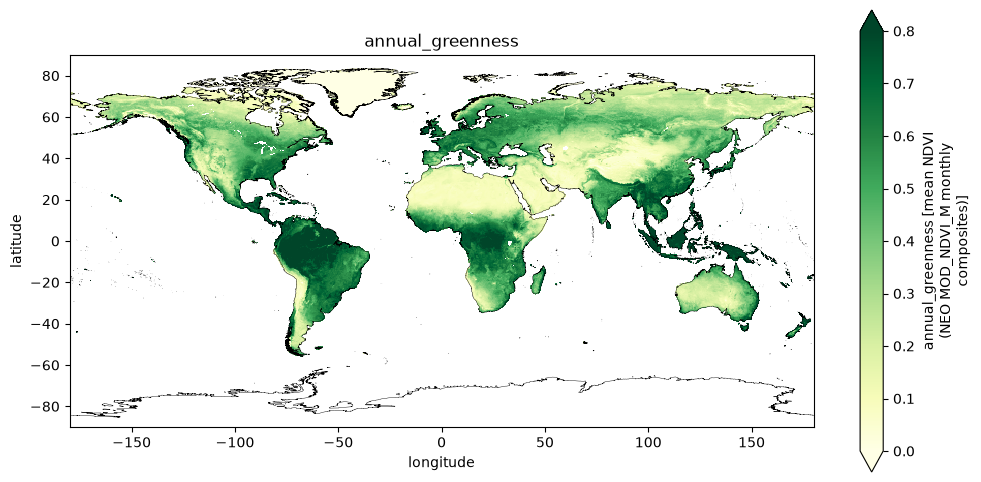

In [5]:
plot_map(values, cmap='YlGn', vmin=0, vmax=0.8)

## 5. Save

In [6]:
out = save_variable(values, VARIABLE)
print(f'wrote {out}')

wrote /Users/lutz/Documents/alfatraining/projects/data-science-notebooks/data/world-livable-atlas/processed/annual_greenness.nc
